In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns

In [8]:
# load mlp output
lstm_output = np.load("../outputs/test_results-2025_07_09_22_32_23.npz")
print(mlp_output.keys())

KeysView(NpzFile '../outputs/test_results-2025_07_09_22_32_23.npz' with keys: inputs, target, outputs)


In [9]:
# Remove first dimension by taking first element since batch size was 1
inputs = lstm_output["inputs"]
targets = lstm_output["target"]
outputs = lstm_output["outputs"]

print("\nAfter reshaping:")
print("Inputs shape: ", inputs.shape)
print("Targets shape: ", targets.shape) 
print("Outputs shape: ", outputs.shape)



After reshaping:
Inputs shape:  (30,)
Targets shape:  (50,)
Outputs shape:  (50,)


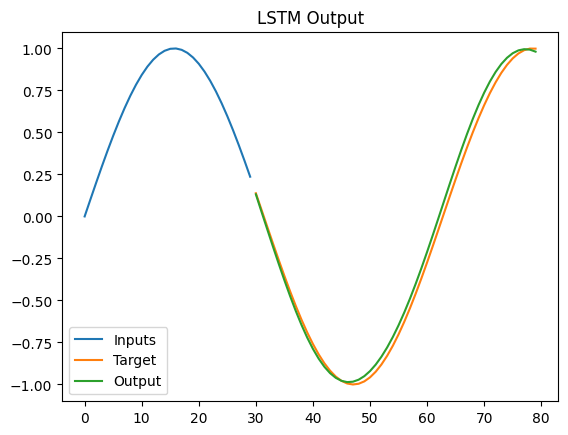

In [10]:
FUTURE_TIMESTEPS = 50

inputs_len = len(inputs)

# generate x axis for inputs and outputs
x_inputs = np.arange(inputs_len)
x_outputs = np.arange(inputs_len, inputs_len + FUTURE_TIMESTEPS)

# plot inputs, outputs
plt.title("LSTM Output")
plt.plot(x_inputs, inputs, label="Inputs")
plt.plot(x_outputs, targets, label="Target")
plt.plot(x_outputs, outputs, label="Output")

plt.legend()
plt.show()

In [11]:
# Step 1: Load the data
lstm_output = np.load("../outputs/test_results-lstm-savar.npz")

outputs = lstm_output["outputs"]
targets = lstm_output["target"]
inputs = lstm_output["inputs"]

print("MLP output shape: ", outputs.shape)
print("MLP target shape: ", targets.shape)
print("MLP inputs shape: ", inputs.shape)

MLP output shape:  (50, 1600)
MLP target shape:  (50, 1600)
MLP inputs shape:  (5, 1600)


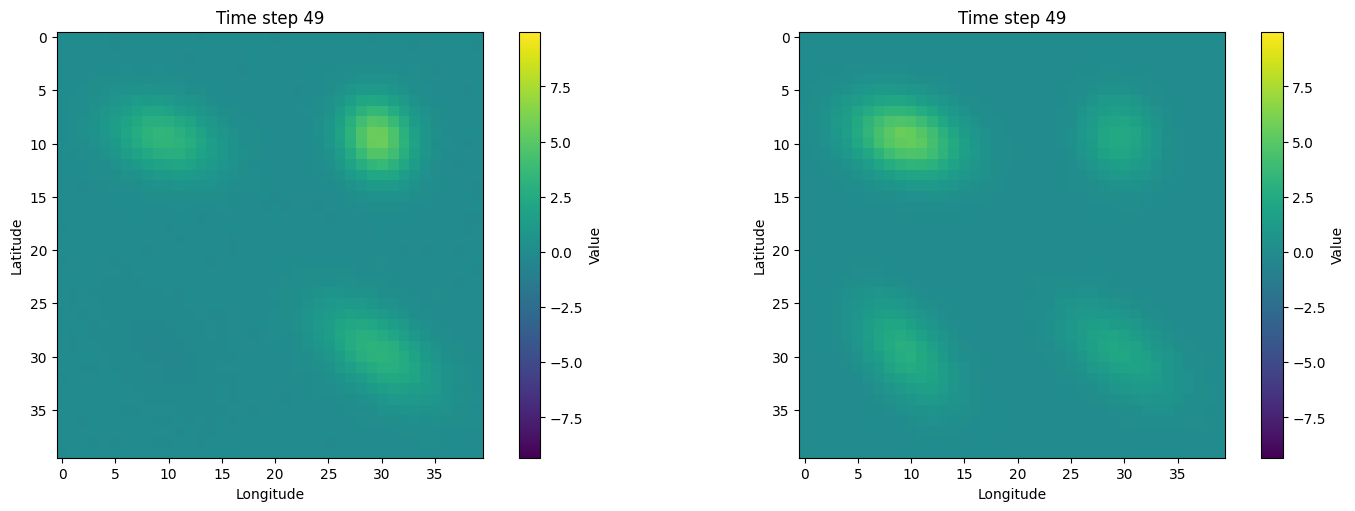

In [12]:
# Reshape targets to 40x40
targets_reshaped = targets.reshape(50, 40, 40)
outputs_reshaped = outputs.reshape(50, 40, 40)

# Get min and max values across both arrays for consistent color scaling
vmin = min(targets_reshaped.min(), outputs_reshaped.min())
vmax = max(targets_reshaped.max(), outputs_reshaped.max())

# Create figure with subplots for target and output comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Initialize heatmaps with same vmin/vmax
im1 = ax1.imshow(targets_reshaped[0, :, :], cmap='viridis', vmin=vmin, vmax=vmax)
im2 = ax2.imshow(outputs_reshaped[0, :, :], cmap='viridis', vmin=vmin, vmax=vmax)

# Add colorbars to both plots with same scale
plt.colorbar(im1, ax=ax1, label='Value')
plt.colorbar(im2, ax=ax2, label='Value')

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()

# Animation update function
def update(frame):

    im1.set_array(targets_reshaped[frame, :, :])
    im2.set_array(outputs_reshaped[frame, :, :])
    ax1.set_title(f'Time step {frame}')
    ax2.set_title(f'Time step {frame}')
    return [im1, im2]

# Create animation
anim = FuncAnimation(fig, update, frames=50, interval=1000, repeat=True, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())
